# 02_treinamento_ml_v3 — Correção do bug de threshold

**O que mudou em relação à v2:** na v2 eu calculei o threshold ótimo (`best_thr`) em cima das probabilidades **não calibradas** do Random Forest (escala 0–100%, média ~40%) e depois apliquei esse mesmo número de corte nas probabilidades **calibradas** (escala 0–57%, média ~6,6%) na hora de gerar a coluna `alto_risco`. Resultado: só 5 pedidos em 110.179 ficavam marcados como alto risco — a flag não servia pra nada.

**A correção:** o threshold agora é calculado *depois* da calibração, direto em cima das probabilidades calibradas — que são as mesmas que vão pro `risco_atraso_perc` no Power BI. Assim os dois usam a mesma régua.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/base_logistica_enriquecida.csv')

## 1. Split sem vazamento (agrupado por `order_id`)

In [2]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['order_id']))
df_train, df_test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

assert len(set(df_train.order_id) & set(df_test.order_id)) == 0, 'Ainda há vazamento entre treino e teste!'
print('Treino:', df_train.shape, '| Teste:', df_test.shape)

Treino: (77130, 13) | Teste: (33049, 13)


## 2. Features: agrupar UFs raras + feature `mesma_uf`

In [3]:
def group_rare(series, ref_counts, min_count=300):
    rare = ref_counts[ref_counts < min_count].index
    return series.where(~series.isin(rare), 'OUTRO')

ref_counts_seller = df_train['seller_state'].value_counts()
ref_counts_cust = df_train['customer_state'].value_counts()

for d in (df_train, df_test):
    d['seller_state_grp'] = group_rare(d['seller_state'], ref_counts_seller)
    d['customer_state_grp'] = group_rare(d['customer_state'], ref_counts_cust)
    d['mesma_uf'] = (d['seller_state'] == d['customer_state']).astype(int)

features_num = ['product_weight_g', 'volume_cm3', 'mes_compra', 'dia_semana_compra', 'mesma_uf']

def build_X(d, ref_cols=None):
    X = pd.get_dummies(d[['seller_state_grp', 'customer_state_grp']], drop_first=True)
    X[features_num] = d[features_num]
    if ref_cols is not None:
        X = X.reindex(columns=ref_cols, fill_value=0)
    return X

X_train = build_X(df_train)
X_test = build_X(df_test, ref_cols=X_train.columns)
y_train, y_test = df_train['houve_atraso'], df_test['houve_atraso']

## 3. Treinamento (Random Forest)

In [4]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=20,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)
print('Modelo treinado.')

Modelo treinado.


## 4. Calibração de probabilidade (agora vem ANTES do threshold)
Essa é a mudança de ordem que corrige o bug: calibramos primeiro, e é em cima do resultado calibrado que vamos escolher o threshold — porque é o calibrado que vai pro Power BI.

In [5]:
modelo_calibrado = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            random_state=42, class_weight='balanced', n_jobs=-1),
    method='isotonic', cv=3
)
modelo_calibrado.fit(X_train, y_train)
proba_cal_teste = modelo_calibrado.predict_proba(X_test)[:, 1]

print('Média das probabilidades calibradas (teste):', round(proba_cal_teste.mean()*100, 2), '%')
print('Taxa real de atraso no teste:                ', round(y_test.mean()*100, 2), '%')
print('ROC-AUC:', roc_auc_score(y_test, proba_cal_teste))
print('PR-AUC:', average_precision_score(y_test, proba_cal_teste))

Média das probabilidades calibradas (teste): 6.61 %
Taxa real de atraso no teste:                 6.57 %
ROC-AUC: 0.7376024911054739
PR-AUC: 0.18703658821296237


## 5. Threshold ajustável — calculado sobre as probabilidades CALIBRADAS
Esta é a correção do bug da v2. O threshold ótimo (F1 máximo) agora sai na mesma escala que o `risco_atraso_perc` que vai para o Power BI (0–100%, média ~6,6%), então o corte de ~12% aqui é diretamente comparável ao filtro que você usa na medida DAX de 'Receita em Risco'.

--- Threshold ótimo calibrado: 12.2% ---
              precision    recall  f1-score   support

           0      0.955     0.891     0.922     30877
           1      0.207     0.404     0.274      2172

    accuracy                          0.859     33049
   macro avg      0.581     0.647     0.598     33049
weighted avg      0.906     0.859     0.879     33049



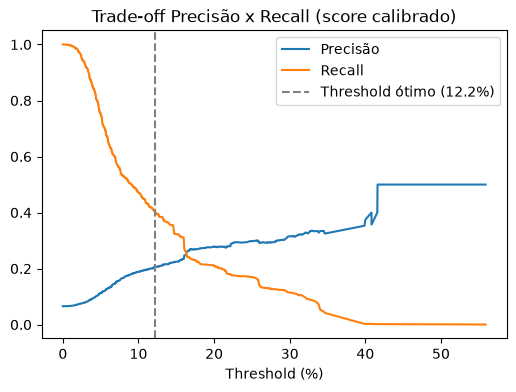

In [6]:
prec, rec, thr = precision_recall_curve(y_test, proba_cal_teste)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thr[np.nanargmax(f1s[:-1])]

print(f'--- Threshold ótimo calibrado: {best_thr*100:.1f}% ---')
print(classification_report(y_test, (proba_cal_teste >= best_thr).astype(int), digits=3))

plt.figure(figsize=(6,4))
plt.plot(thr*100, prec[:-1], label='Precisão')
plt.plot(thr*100, rec[:-1], label='Recall')
plt.axvline(best_thr*100, color='gray', linestyle='--', label=f'Threshold ótimo ({best_thr*100:.1f}%)')
plt.xlabel('Threshold (%)'); plt.legend(); plt.title('Trade-off Precisão x Recall (score calibrado)')
plt.show()

# Nota: se preferir um corte mais conservador (menos pedidos marcados, maior precisão),
# 15-20% também é uma escolha razoável -- veja a tabela de trade-off acima do threshold ótimo.
# O valor de 'best_thr' aqui é o que maximiza F1, não necessariamente o ideal pro seu processo operacional.

## 6. O que mais pesa na previsão

mes_compra               0.378947
volume_cm3               0.110687
product_weight_g         0.107557
customer_state_grp_SP    0.067394
customer_state_grp_RJ    0.059138
mesma_uf                 0.053296
dia_semana_compra        0.046899
customer_state_grp_MG    0.030650
customer_state_grp_PR    0.023059
seller_state_grp_SP      0.020564
dtype: float64


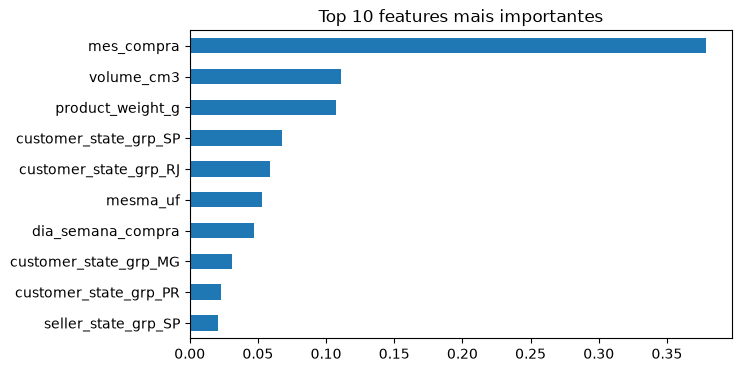

In [7]:
fi = pd.Series(modelo_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(fi.head(10))

plt.figure(figsize=(7,4))
fi.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 features mais importantes')
plt.show()

## 7. Exportação para o Power BI
Treina o modelo calibrado na base inteira e aplica o **mesmo threshold calibrado** (`best_thr`) calculado no passo 5 -- essa é a correção principal em relação à v2.

In [8]:
ref_counts_seller_full = df['seller_state'].value_counts()
ref_counts_cust_full = df['customer_state'].value_counts()
df['seller_state_grp'] = group_rare(df['seller_state'], ref_counts_seller_full)
df['customer_state_grp'] = group_rare(df['customer_state'], ref_counts_cust_full)
df['mesma_uf'] = (df['seller_state'] == df['customer_state']).astype(int)
X_full = build_X(df, ref_cols=X_train.columns)

modelo_final = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            random_state=42, class_weight='balanced', n_jobs=-1),
    method='isotonic', cv=3
)
modelo_final.fit(X_full, df['houve_atraso'])
probabilidades = modelo_final.predict_proba(X_full)[:, 1]

df_powerbi = df.copy()
df_powerbi['risco_atraso_perc'] = (probabilidades * 100).round(2)
df_powerbi['alto_risco'] = (probabilidades >= best_thr).astype(int)  # <-- agora na MESMA escala

print('Pedidos marcados como alto_risco:', df_powerbi["alto_risco"].sum(),
      f'({df_powerbi["alto_risco"].mean()*100:.1f}% da base)')

caminho_bi = '../data/processed/base_para_powerbi.csv'
df_powerbi.to_csv(caminho_bi, index=False)
print('Base final exportada:', caminho_bi)

Pedidos marcados como alto_risco: 15536 (14.1% da base)
Base final exportada: ../data/processed/base_para_powerbi.csv
